# NHS A&E Forecasting — Model comparison and Risk Classification

**Project:** AI-Driven Operational Decision Support in NHS Emergency Care

This notebook builds and compares multiple machine learning models by creating confusion matrix.

In [1]:
# install python necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay,
)


In [2]:
# setup and load the data
df = pd.read_csv("Dataset/02_clean_Monthly_AE_data.csv", parse_dates=["Month"])

# Drop the first 3 years of rows, which have no SeasonalBaselineAvg yet (not enough prior history)
df = df[df["RiskFlag"] != "N/A - not enough prior years yet"].copy()
print("Rows available for modelling:", len(df))

Rows available for modelling: 179


## Feature engineering

In [ ]:
# extract all the features for forecasting
FEATURES = [
    "Year", "MonthSin", "MonthCos", "MajorShare_x_Winter",
    "MajorAE_SharePct", "SeasonalBaselineAvg",
    "Attendances_Lag1", "Attendances_RollingMean3",
    "AdmissionRate", "Breach12hrRate", "MajorInjuryPerformancePct",
]

# Drop any row missing a value in any of these columns (mainly the first couple of months, where Lag1/RollingMean3 can't be calculated yet).
model_df = df.dropna(subset=FEATURES + ["TotalAttendances", "RiskFlag"]).reset_index(drop=True)
print(f"{len(FEATURES)} features, {len(model_df)} usable rows")
model_df[FEATURES].head()

11 features, 179 usable rows


,Year,MonthSin,MonthCos,MajorShare_x_Winter,MajorAE_SharePct,SeasonalBaselineAvg,Attendances_Lag1,Attendances_RollingMean3,AdmissionRate,Breach12hrRate,MajorInjuryPerformancePct
0,2011,-8.660254e-01,-5.000000e-01,0.00,64.60,1.752381e+06,1.864959e+06,1.841357e+06,23.35,0.000,96.1
1,2011,-1.000000e+00,-1.836970e-16,0.00,65.24,1.756268e+06,1.758108e+06,1.802828e+06,23.06,0.001,95.3
2,2011,-8.660254e-01,5.000000e-01,0.00,64.94,1.801348e+06,1.781211e+06,1.801426e+06,23.53,0.002,94.9
3,2011,-5.000000e-01,8.660254e-01,0.00,65.17,1.651027e+06,1.848912e+06,1.796077e+06,24.40,0.002,94.9
4,2011,-2.449294e-16,1.000000e+00,65.91,65.91,1.737741e+06,1.741441e+06,1.790521e+06,25.50,0.000,93.7


## Prepare data for ML model

In [4]:
# 5 fold cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validation strategy: 5-fold, shuffled, random_state=42")

Cross-validation strategy: 5-fold, shuffled, random_state=42


## Forecasting TotalAttendances

In [5]:
# by comparing different model
X = model_df[FEATURES]
y_reg = model_df["TotalAttendances"]

regression_models = {
    "Linear Regression": LinearRegression(),
    "kNN": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
}

rows = []
for name, model in regression_models.items():
    scores = cross_validate(
        model, X, y_reg, cv=cv,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    )
    rows.append({
        "Model": name,
        "RMSE": round(-scores["test_neg_root_mean_squared_error"].mean(), 0),
        "MAE": round(-scores["test_neg_mean_absolute_error"].mean(), 0),
        "R2": round(scores["test_r2"].mean(), 3),
    })

regression_results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
regression_results

,Model,RMSE,MAE,R2
0,Linear Regression,73049.0,58184.0,0.903
1,kNN,89511.0,61906.0,0.859
2,Random Forest,90711.0,61526.0,0.857


## check all model against baseline

In [6]:
# comparing the best model against seasonal-naive baseline

baseline_rmse = np.sqrt(((model_df["TotalAttendances"] - model_df["SeasonalBaselineAvg"]) ** 2).mean())
best_model_row = regression_results.iloc[0]
improvement = (1 - best_model_row["RMSE"] / baseline_rmse) * 100

print(f"Seasonal-naive baseline RMSE:  {baseline_rmse:,.0f} patients")
print(f"Best model ({best_model_row['Model']}) RMSE: {best_model_row['RMSE']:,.0f} patients")
print(f"Improvement over baseline: {improvement:.1f}%")
print()
print(f"This is the one sentence this whole track exists to produce: the {best_model_row['Model']}")
print(f"model beats a plain seasonal average by {improvement:.1f}%, which is the justification for")
print(f"using a trained model instead of a fixed seasonal average.")

Seasonal-naive baseline RMSE:  231,823 patients
Best model (Linear Regression) RMSE: 73,049 patients
Improvement over baseline: 68.5%

This is the one sentence this whole track exists to produce: the Linear Regression
model beats a plain seasonal average by 68.5%, which is the justification for
using a trained model instead of a fixed seasonal average.


## Why AttendanceGrowthRatio was excluded - shown directly, not just claimed 

In [7]:
# reason for excluding the feature

model_df["AttendanceGrowthRatio"] = model_df["TotalAttendances"] / model_df["SeasonalBaselineAvg"]

X_leaky = model_df[FEATURES + ["AttendanceGrowthRatio"]]

leaky_model = LinearRegression()
leaky_scores = cross_validate(leaky_model, X_leaky, y_reg, cv=cv,
                                scoring=["neg_root_mean_squared_error", "r2"])
leaky_rmse = -leaky_scores["test_neg_root_mean_squared_error"].mean()
leaky_r2 = leaky_scores["test_r2"].mean()

clean_rmse = regression_results.loc[regression_results["Model"] == "Linear Regression", "RMSE"].values[0]
clean_r2 = regression_results.loc[regression_results["Model"] == "Linear Regression", "R2"].values[0]

print("Linear Regression, WITH the leaking feature included:")
print(f"  RMSE: {leaky_rmse:,.0f}   R2: {leaky_r2:.3f}")
print()
print("Linear Regression, WITHOUT it (the version actually used):")
print(f"  RMSE: {clean_rmse:,.0f}   R2: {clean_r2:.3f}")
print()
print("The suspiciously perfect score with the feature included is the signature of data")
print("leakage, not a genuinely better model — this is why it was removed.")

Linear Regression, WITH the leaking feature included:
  RMSE: 14,306   R2: 0.996

Linear Regression, WITHOUT it (the version actually used):
  RMSE: 73,049   R2: 0.903

The suspiciously perfect score with the feature included is the signature of data
leakage, not a genuinely better model — this is why it was removed.


## Classifying RiskFlag (low/medium/high)

In [8]:
# comparing different classification model

y_clf = model_df["RiskFlag"]

classification_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

rows = []
predictions_by_model = {}
for name, model in classification_models.items():
    preds = cross_val_predict(model, X, y_clf, cv=cv)
    predictions_by_model[name] = preds
    acc = accuracy_score(y_clf, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_clf, preds, average="macro", zero_division=0)
    rows.append({"Model": name, "Accuracy": round(acc,3), "Precision": round(prec,3),
                 "Recall": round(rec,3), "F1": round(f1,3)})

classification_results = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
classification_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.771,0.764,0.763,0.762
1,kNN,0.726,0.734,0.707,0.719
2,Random Forest,0.721,0.730,0.699,0.712


## Confusion Matrix

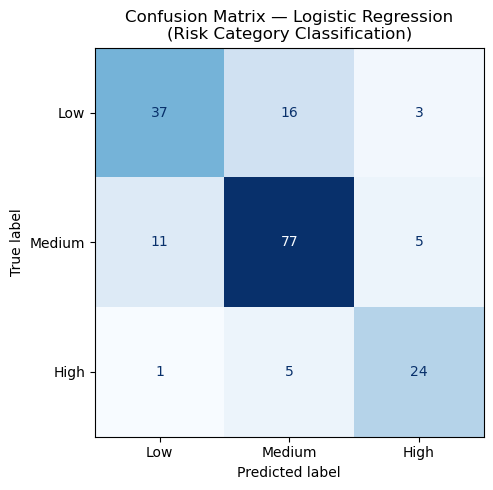

               Predicted Low  Predicted Medium  Predicted High
Actual Low                37                16               3
Actual Medium             11                77               5
Actual High                1                 5              24


In [9]:
best_clf_name = classification_results.iloc[0]["Model"]
best_preds = predictions_by_model[best_clf_name]
labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_clf, best_preds, labels=labels)

import os
os.makedirs("outputs", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues", ax=ax, colorbar=False)
plt.title(f"Confusion Matrix — {best_clf_name}\n(Risk Category Classification)")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=200)
plt.show()

cm_df = pd.DataFrame(cm, index=[f"Actual {l}" for l in labels], columns=[f"Predicted {l}" for l in labels])
print(cm_df)

## Interpreting the matrix

In [10]:
def count_direction(cm, labels):
    order = {l: i for i, l in enumerate(labels)}  # Low=0, Medium=1, High=2
    under = over = 0
    for i, actual in enumerate(labels):
        for j, predicted in enumerate(labels):
            if i == j:
                continue
            count = cm[i][j]
            if order[predicted] < order[actual]:
                under += count   # predicted a lower risk than it actually was
            else:
                over += count    # predicted a higher risk than it actually was
    return under, over

under_warn, over_warn = count_direction(cm, labels)
total_errors = under_warn + over_warn
total_months = cm.sum()

print(f"Best classifier: {best_clf_name}")
print(f"Overall accuracy: {accuracy_score(y_clf, best_preds):.1%}  ({total_months - total_errors} of {total_months} months correct)")
print(f"Under-warning errors (actual risk higher than predicted): {under_warn}")
print(f"Over-warning errors (actual risk lower than predicted): {over_warn}")
print()
if under_warn > over_warn:
    print("Under-warning is the more common error type here — worth flagging directly: the model")
    print("more often misses that risk was higher than expected, rather than the safer mistake of")
    print("over-preparing. This is the honest caveat to raise proactively in the next meeting.")
elif over_warn > under_warn:
    print("Over-warning is the more common error type here — the safer direction of mistake: the")
    print("model more often flags MORE risk than there actually was, rather than missing real risk.")
else:
    print("Errors run evenly in both directions — no systematic bias toward under- or over-warning.")

Best classifier: Logistic Regression
Overall accuracy: 77.1%  (138 of 179 months correct)
Under-warning errors (actual risk higher than predicted): 17
Over-warning errors (actual risk lower than predicted): 24

Over-warning is the more common error type here — the safer direction of mistake: the
model more often flags MORE risk than there actually was, rather than missing real risk.


## Prepare inputs for PowerBI

In [11]:
import os
os.makedirs("outputs", exist_ok=True)

regression_results.to_csv("outputs/model_comparison_regression.csv", index=False)
classification_results.to_csv("outputs/model_comparison_classification.csv", index=False)
cm_df.to_csv("outputs/confusion_matrix.csv")
# confusion_matrix.png was already saved to outputs/ in the cell that built it, above

# Predictions table for Power BI (Month, actual, predicted for the winning models)
best_reg_model = regression_models[regression_results.iloc[0]["Model"]]
best_reg_model.fit(X, y_reg)
model_df_out = model_df[["Month", "TotalAttendances", "RiskFlag"]].copy()
model_df_out["PredictedTotalAttendances"] = best_reg_model.predict(X).round(0)
model_df_out["PredictedRiskFlag"] = best_preds
model_df_out.to_csv("outputs/predictions_with_riskflag.csv", index=False)

print("Saved to outputs/:")
print(" - model_comparison_regression.csv")
print(" - model_comparison_classification.csv")
print(" - confusion_matrix.csv")
print(" - predictions_with_riskflag.csv")

Saved to outputs/:
 - model_comparison_regression.csv
 - model_comparison_classification.csv
 - confusion_matrix.csv
 - predictions_with_riskflag.csv
